<a href="https://colab.research.google.com/github/baramitha/bt4222/blob/main/Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading


In [ ]:
import pandas as pd

anime_clean = pd.read_csv('/content/anime_clean.csv')
users_sampled = pd.read_csv('/content/users_sampled.csv')
ratings_sampled = pd.read_csv('/content/ratings_sampled.csv')

### Feature Engineering

To provide our model with more predictive power, we transform raw ratings and metadata into meaningful features. This step bridges the gap between raw data and machine learning.

#### 1. Item-Level (Anime) Features
- **`num_scores`**: The total number of ratings an anime received within our sample, representing its popularity density.
- Other features related to anime are incorporated as user features in the next part.

In [13]:
# Number of Ratings Received by Each Anime
num_scores = (
    ratings_sampled
    .groupby('anime_id')['rating']
    .count()
    .reset_index(name='num_scores')
)

print(num_scores.head())

   anime_id  num_scores
0         1       66152
1         5       19292
2         6       36583
3         7        9726
4         8        1182


#### 2. User-Level Features
We calculate aggregate statistics for each user based on their historical behavior in the sampled dataset:
- **`num_ratings`**: Total count of ratings provided (measures activity/confidence).
- **`avg_rating`**: The user's mean score across all anime (captures personal bias/strictness).
- **`rating_std`**: Standard deviation of ratings (identifies how varied a user's tastes are).
- **`avg_popularity_rated`**: The mean popularity rank of the anime a user has watched (distinguishes 'mainstream' from 'niche' fans).
- **`avg_rating_genre`**:
- **`most_rated_genre`**:

In [14]:
# num_ratings
num_ratings = (
    ratings_sampled
    .groupby('user_id')['rating']
    .count()
    .reset_index(name='num_ratings')
)


# compute average rating that a user has given to all anime
# average rating per user
avg_rating = (
    ratings_sampled
    .groupby('user_id', as_index=False)['rating']
    .mean()
    .rename(columns={'rating': 'avg_rating'})
)

# rating std per user
rating_std = (
    ratings_sampled
    .groupby('user_id', as_index=False)['rating']
    .std()
    .rename(columns={'rating': 'rating_std'})
)
rating_std['rating_std'] = rating_std['rating_std'].fillna(0)

# average popularity of anime rated by each user
anime_pop = anime_clean[['anime_id', 'Popularity']].copy()

ratings_popularity = ratings_sampled[['user_id', 'anime_id']].merge(
    anime_pop,
    on='anime_id',
    how='left'
)
avg_popularity_rated = (
    ratings_popularity
    .groupby('user_id', as_index=False)['Popularity']
    .mean()
    .rename(columns={'Popularity': 'avg_popularity_rated'})
)


# Combine User-Level Features
user_features = num_ratings.merge(avg_rating, on='user_id', how='left')
user_features = user_features.merge(rating_std, on='user_id', how='left')
user_features = user_features.merge(avg_popularity_rated, on='user_id', how='left')

# Change genres into category type
anime_genres = anime_clean[['anime_id', 'Genres']].copy()
anime_genres['genre'] = anime_genres['Genres'].str.split(', ')
anime_genres = anime_genres.explode('genre')
anime_genres['genre'] = anime_genres['genre'].astype('category')
anime_genres = anime_genres[['anime_id', 'genre']]


anime_genres['anime_id'] = anime_genres['anime_id'].astype('int32')


ratings_sampled['user_id'] = ratings_sampled['user_id'].astype('int32')
ratings_sampled['anime_id'] = ratings_sampled['anime_id'].astype('int32')
ratings_sampled['rating'] = ratings_sampled['rating'].astype('float32')

# create chunks and process as batches to save memory
chunk_size = 200_000

all_user_genre_stats = []

for start in range(0, len(ratings_sampled), chunk_size):
    end = start + chunk_size
    chunk = ratings_sampled.iloc[start:end][['user_id', 'anime_id', 'rating']].copy()

    merged = chunk.merge(anime_genres, on='anime_id', how='left')

    stats = (
        merged.groupby(['user_id', 'genre'], observed=True)
        .agg(
            rating_sum=('rating', 'sum'),
            genre_rating_count=('rating', 'count')
        )
        .reset_index()
    )

    all_user_genre_stats.append(stats)

user_genre_stats = pd.concat(all_user_genre_stats, ignore_index=True)

user_genre_stats = (
    user_genre_stats.groupby(['user_id', 'genre'], observed=True, as_index=False)
    .agg(
        rating_sum=('rating_sum', 'sum'),
        genre_rating_count=('genre_rating_count', 'sum')
    )
)

user_genre_stats['avg_rating_genre'] = (
    user_genre_stats['rating_sum'] / user_genre_stats['genre_rating_count']
).astype('float32')


# most rated genre
most_rated_genre = (
    user_genre_stats
    .sort_values(['user_id', 'genre_rating_count'], ascending=[True, False])
    .drop_duplicates('user_id')
    [['user_id', 'genre']]
    .rename(columns={'genre': 'most_rated_genre'})
)


# Avg rating of most rated genre
avg_rating_most_rated_genre = (
    user_genre_stats
    .sort_values(['user_id', 'genre_rating_count'], ascending=[True, False])
    .drop_duplicates('user_id')
    [['user_id', 'avg_rating_genre']]
    .rename(columns={'avg_rating_genre': 'avg_rating_most_rated_genre'})
)


user_features = user_features.merge(
    most_rated_genre,
    on='user_id',
    how='left'
)

user_features = user_features.merge(
    avg_rating_most_rated_genre,
    on='user_id',
    how='left'
)

display(
    user_features[
        ['user_id', 'num_ratings', 'avg_rating', 'rating_std',
         'avg_popularity_rated', 'most_rated_genre', 'avg_rating_most_rated_genre']
    ].head().round(3)
)

display(
    user_genre_stats[
        ['user_id', 'genre', 'avg_rating_genre', 'genre_rating_count']
    ].head(50).round(3)
)


,user_id,num_ratings,avg_rating,rating_std,avg_popularity_rated,most_rated_genre,avg_rating_most_rated_genre
0,0,74,4.811,3.989,1607.730,Comedy,5.050
1,1,139,6.777,3.137,515.324,Shounen,6.934
2,2,494,0.957,2.678,3219.555,Hentai,0.247
3,5,194,1.928,3.565,1236.943,Comedy,1.920
4,7,156,4.609,3.999,545.513,Romance,4.529


,user_id,genre,avg_rating_genre,genre_rating_count
0,0,Action,4.308,26
1,0,Adventure,5.400,35
2,0,Comedy,5.050,40
3,0,Demons,0.000,3
4,0,Drama,4.857,28
5,0,Ecchi,4.000,1
6,0,Fantasy,5.261,23
7,0,Game,3.400,5
8,0,Harem,0.000,1
9,0,Historical,6.333,9


#### 3. Derived Features
- **Sentiment Analysis**: We categorize numerical ratings into qualitative buckets:
    - **Negative**: ≤ 5
    - **Neutral**: 6 - 8
    - **Positive**: 9 - 10
- **Mean Anime Popularity**: A user-centric feature that tracks the average 'mainstream-ness' of a user's library, merged back into the user details for segmentation analysis.

In [15]:
# Sentiment Derived from Rating
def map_sentiment(rating):
    if rating <= 5:
        return 'Negative'
    elif rating <= 8:
        return 'Neutral'
    else:
        return 'Positive'

ratings_sampled['sentiment'] = ratings_sampled['rating'].apply(map_sentiment)

print(ratings_sampled[['user_id', 'anime_id', 'rating', 'sentiment']].head())

   user_id  anime_id  rating sentiment
0        0        67     9.0  Positive
1        0      6702     7.0   Neutral
2        0       242    10.0  Positive
3        0      4898     0.0  Negative
4        0        21    10.0  Positive


### K-means analysis

k=2, inertia=1964336.15, silhouette=0.2047
k=3, inertia=1920160.34, silhouette=0.1135
k=4, inertia=1891739.23, silhouette=0.1975
k=5, inertia=1845310.42, silhouette=0.1050
k=6, inertia=1792635.81, silhouette=0.2464


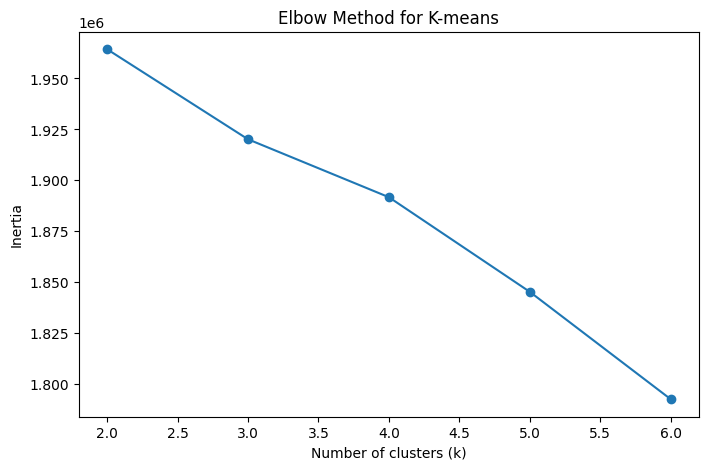

Cluster summary:
         num_ratings  avg_rating  rating_std  avg_popularity_rated  \
cluster                                                              
0            1450.33        3.87        2.92               2417.89   
1             175.12        6.33        3.13                985.69   
2             203.98        3.16        3.37                838.32   
3             119.26        6.96        2.77                696.47   
4             241.22        2.43        3.07               1059.83   
5             166.64        3.50        2.14               4720.93   

         avg_rating_most_rated_genre  
cluster                               
0                               4.00  
1                               6.45  
2                               3.27  
3                               7.08  
4                               2.45  
5                               3.39  

Cluster sizes:
cluster
0     4621
1    64446
2    33503
3    38361
4    41259
5     1423
Name: count, dtype: 

,cluster,cluster_size,cluster_pct,dominant_genre,num_ratings_mean,avg_rating_mean,rating_std_mean,avg_popularity_rated_mean
0,0,4621,2.52,Comedy,1450.33,3.87,2.92,2417.89
1,1,64446,35.10,Comedy,175.12,6.33,3.13,985.69
2,2,33503,18.25,Action,203.98,3.16,3.37,838.32
3,3,38361,20.89,Action,119.26,6.96,2.77,696.47
4,4,41259,22.47,Comedy,241.22,2.43,3.07,1059.83
5,5,1423,0.77,Hentai,166.64,3.50,2.14,4720.93


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Prepare data
kmeans_data = user_features.copy()

kmeans_data['avg_rating_most_rated_genre'] = kmeans_data['avg_rating_most_rated_genre'].fillna(0)
kmeans_data['avg_popularity_rated'] = kmeans_data['avg_popularity_rated'].fillna(0)
kmeans_data['rating_std'] = kmeans_data['rating_std'].fillna(0)
kmeans_data['most_rated_genre'] = kmeans_data['most_rated_genre'].fillna('Unknown')

kmeans_encoded = pd.get_dummies(
    kmeans_data,
    columns=['most_rated_genre'],
    drop_first=False
)

X = kmeans_encoded.drop(columns=['user_id'])

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


sample_size = min(50000, len(X))
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=10
    )
    labels = kmeans.fit_predict(X_sample)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels))
    print(f"k={k}, inertia={kmeans.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}")


# Elbow plot to determine number of clusters
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-means')
plt.show()



# k means analysis
optimal_k = 6
kmeans_final = MiniBatchKMeans(
    n_clusters=optimal_k,
    random_state=42,
    batch_size=10000,
    n_init=10
)
user_features['cluster'] = kmeans_final.fit_predict(X_scaled)



# Cluster summary

cluster_summary = user_features.groupby('cluster')[
    ['num_ratings', 'avg_rating', 'rating_std', 'avg_popularity_rated', 'avg_rating_most_rated_genre']
].mean()

print("Cluster summary:")
print(cluster_summary.round(2))

print("\nCluster sizes:")
print(user_features['cluster'].value_counts().sort_index())

cluster_genre_summary = (
    user_features.groupby('cluster')['most_rated_genre']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name='dominant_genre')
)

print("\nDominant genre in each cluster:")
print(cluster_genre_summary)

# Cluster table

cluster_profile = user_features.groupby('cluster').agg(
    cluster_size=('cluster', 'size'),num_ratings_mean=('num_ratings', 'mean'),avg_rating_mean=('avg_rating', 'mean'),
    rating_std_mean=('rating_std', 'mean'),avg_popularity_rated_mean=('avg_popularity_rated', 'mean'),avg_rating_most_rated_genre_mean=('avg_rating_most_rated_genre', 'mean')
).reset_index()
cluster_profile['cluster_pct'] = (cluster_profile['cluster_size'] / cluster_profile['cluster_size'].sum() * 100
).round(2)
dominant_genre_table = (
    user_features.groupby('cluster')['most_rated_genre'].agg(lambda x: x.value_counts().index[0]).reset_index(name='dominant_genre')
)
cluster_profile = cluster_profile.merge(dominant_genre_table, on='cluster', how='left')
cluster_profile = cluster_profile[
    ['cluster', 'cluster_size', 'cluster_pct', 'dominant_genre','num_ratings_mean', 'avg_rating_mean', 'rating_std_mean', 'avg_popularity_rated_mean', 'avg_rating_most_rated_genre_mean']
]
print("\nCluster profile table:")
print(cluster_profile.round(2))

cluster_table = user_features.groupby('cluster').agg(
    cluster_size=('cluster', 'size'),
    num_ratings_mean=('num_ratings', 'mean'),
    avg_rating_mean=('avg_rating', 'mean'),
    rating_std_mean=('rating_std', 'mean'),
    avg_popularity_rated_mean=('avg_popularity_rated', 'mean'),
    avg_rating_most_rated_genre_mean=('avg_rating_most_rated_genre', 'mean')
).reset_index()

# percentage of total users
cluster_table['cluster_pct'] = (
    cluster_table['cluster_size'] / cluster_table['cluster_size'].sum() * 100
).round(2)

# dominant genre
dominant_genre_table = (
    user_features.groupby('cluster')['most_rated_genre']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index(name='dominant_genre')
)

cluster_table = cluster_table.merge(dominant_genre_table, on='cluster', how='left')

# reorder columns
cluster_table = cluster_table[
    ['cluster', 'cluster_size', 'cluster_pct', 'dominant_genre',
     'num_ratings_mean', 'avg_rating_mean', 'rating_std_mean',
     'avg_popularity_rated_mean']
].round(2)

display(cluster_table)
